In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import tqdm
from pybedtools import BedTool

In [2]:
df_hap1_hifi = pd.read_csv(f'/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/hifi_reads_to_hs1.minimap2.haplotagged_ground_truth.hap1.bed.gz',
                      sep='\t', names=['chrom', 'start', 'end', 'score', 'hap',
                                       'coverage', 'mod_count', 'unmod_count','ratio'], 
                      engine='pyarrow', skiprows=7)
df_hap2_hifi = pd.read_csv(f'/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/hifi_reads_to_hs1.minimap2.haplotagged_ground_truth.hap2.bed.gz',
                      sep='\t', names=['chrom', 'start', 'end', 'score', 'hap',
                                       'coverage', 'mod_count', 'unmod_count','ratio'], 
                      engine='pyarrow', skiprows=7)

df_hap1_ont = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp1.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

df_hap2_ont = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp2.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

df_hap1_ul_ont = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ul_ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp1.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])
df_hap2_ul_ont = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ul_ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp2.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

In [3]:
df_hap1_hifi_icr = pd.read_csv(f'/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/hifi_reads_to_hs1.minimap2.haplotagged_ground_truth.hap1.icr.bed',
                      sep='\t', names=['chrom', 'start', 'end', 'score', 'hap',
                                       'coverage', 'mod_count', 'unmod_count','ratio'], 
                      engine='pyarrow', skiprows=7)
df_hap2_hifi_icr = pd.read_csv(f'/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/hifi_reads_to_hs1.minimap2.haplotagged_ground_truth.hap2.icr.bed',
                      sep='\t', names=['chrom', 'start', 'end', 'score', 'hap',
                                       'coverage', 'mod_count', 'unmod_count','ratio'], 
                      engine='pyarrow', skiprows=7)

df_hap1_ont_icr = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp1.icr.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

df_hap2_ont_icr = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp2.icr.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

df_hap1_ul_ont_icr = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ul_ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp1.icr.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])
df_hap2_ul_ont_icr = pd.read_csv('/scratch/gpfs/AKEY/apfennig/LongHap/HG002/alignments/ul_ont_r10.4.1_dorado_reads_to_hs1.minimap2.haplotagged_ground_truth_modkit/hp2.icr.bedmethyl',
                             sep='\t', engine='pyarrow',
                             names=['chrom', 'start', 'end', 'coverage', 'ratio',
                                    'mod_count', 'unmod_count'],
                            usecols=[0, 1, 2, 4, 10, 11, 12])

In [4]:
df_hap1_hifi_icr = df_hap1_hifi_icr[df_hap1_hifi_icr.coverage >= 10]
df_hap2_hifi_icr = df_hap2_hifi_icr[df_hap2_hifi_icr.coverage >= 10]

df_hap1_ont_icr = df_hap1_ont_icr[df_hap1_ont_icr.coverage >= 10]
df_hap2_ont_icr = df_hap2_ont_icr[df_hap2_ont_icr.coverage >= 10]

df_hap1_ul_ont_icr = df_hap1_ul_ont_icr[df_hap1_ul_ont_icr.coverage >= 10]
df_hap2_ul_ont_icr = df_hap2_ul_ont_icr[df_hap2_ul_ont_icr.coverage >= 10]

In [5]:
df_hap1_hifi = df_hap1_hifi[df_hap1_hifi.coverage >= 10]
df_hap2_hifi = df_hap2_hifi[df_hap2_hifi.coverage >= 10]

df_hap1_ont = df_hap1_ont[df_hap1_ont.coverage >= 10]
df_hap2_ont = df_hap2_ont[df_hap2_ont.coverage >= 10]

df_hap1_ul_ont = df_hap1_ul_ont[df_hap1_ul_ont.coverage >= 10]
df_hap2_ul_ont = df_hap2_ul_ont[df_hap2_ul_ont.coverage >= 10]

In [6]:
df_hifi = df_hap1_hifi.set_index(['chrom', 'start', 'end']).join(df_hap2_hifi.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_hifi.dropna(inplace=True)

df_ont = df_hap1_ont.set_index(['chrom', 'start', 'end']).join(df_hap2_ont.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_ont.dropna(inplace=True)

df_ul_ont = df_hap1_ul_ont.set_index(['chrom', 'start', 'end']).join(df_hap2_ul_ont.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_ul_ont.dropna(inplace=True)



{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x154fd41222a0>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x154fed2a1370>,
 'cmins': <matplotlib.collections.LineCollection at 0x154fd4197e90>,
 'cbars': <matplotlib.collections.LineCollection at 0x154fd41b88f0>}

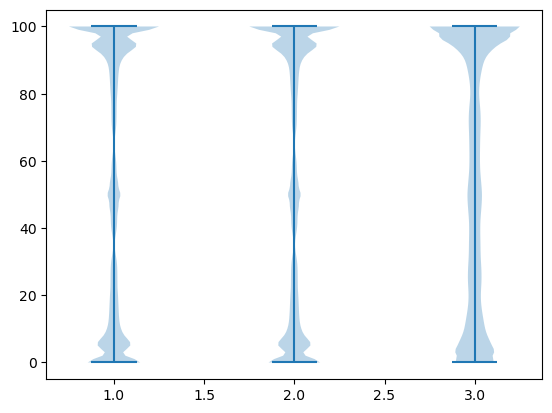

In [13]:
fig, ax = plt.subplots()
ax.violinplot([df_hifi.ratio_1.values, df_hifi.ratio_2.values, 
               ((df_hifi.mod_count_1.values + df_hifi.mod_count_2.values) / 
                (df_hifi.mod_count_1.values + df_hifi.mod_count_2.values + 
                 df_hifi.unmod_count_1.values + df_hifi.unmod_count_2.values)) * 100])

In [12]:
df_hifi

score_1 hap_1  coverage_1  mod_count_1  \
chrom start    end                                                
chr1  2877     2878         96.0  hap1          13           13   
      2880     2881         95.7  hap1          13           13   
      2886     2887         94.9  hap1          13           13   
      2896     2897         91.9  hap1          13           12   
      2898     2899         92.2  hap1          13           12   
...                          ...   ...         ...          ...   
chr21 45063364 45063365     81.3  hap1          23           19   
      45063384 45063385     75.7  hap1          23           18   
      45063423 45063424     49.6  hap1          23           12   
      45063480 45063481     92.0  hap1          23           22   
      45063495 45063496     15.9  hap1          23            3   

                         unmod_count_1  ratio_1  score_2 hap_2  coverage_2  \
chrom start    end                                                           
chr1  2877     2878                  0    100.0     94.9  hap2        18.0   
      2880     2881                  0    100.0     92.1  hap2        18.0   
      2886     2887                  0    100.0     94.5  hap2        18.0   
      2896     2897                  1     92.3     92.9  hap2        18.0   
      2898     2899                  1     92.3     93.0  hap2        18.0   
...                                ...      ...      ...   ...         ...   
chr21 45063364 45063365              4     82.6     82.3  hap2        11.0   
      45063384 45063385              5     78.3     61.0  hap2        11.0   
      45063423 45063424             11     52.2     57.2  hap2        10.0   
      45063480 45063481              1     95.7     93.9  hap2        10.0   
      45063495 45063496             20     13.0     60.6  hap2        10.0   

                         mod_count_2  unmod_count_2  ratio_2  
chrom start    end                                            
chr1  2877     2878             18.0            0.0    100.0  
      2880     2881             17.0            1.0     94.4  
      2886     2887             18.0            0.0    100.0  
      2896     2897             17.0            1.0     94.4  
      2898     2899             17.0            1.0     94.4  
...                              ...            ...      ...  
chr21 45063364 45063365         10.0            1.0     90.9  
      45063384 45063385          6.0            5.0     54.5  
      45063423 45063424          5.0            5.0     50.0  
      45063480 45063481         10.0            0.0    100.0  
      45063495 45063496          6.0            4.0     60.0  

[21947188 rows x 12 columns]

In [7]:
df_hifi_icr = df_hap1_hifi_icr.set_index(['chrom', 'start', 'end']).join(df_hap2_hifi_icr.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_hifi_icr.dropna(inplace=True)

df_ont_icr = df_hap1_ont_icr.set_index(['chrom', 'start', 'end']).join(df_hap2_ont_icr.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_ont_icr.dropna(inplace=True)

df_ul_ont_icr = df_hap1_ul_ont_icr.set_index(['chrom', 'start', 'end']).join(df_hap2_ul_ont_icr.set_index(['chrom', 'start', 'end']),
                                                                 lsuffix='_1', rsuffix='_2')
df_ul_ont_icr.dropna(inplace=True)

In [8]:
base_dir = '/scratch/gpfs/AKEY/apfennig/LongHap/HG002/deepvariant/'
diff_meth_hifi = pd.concat([pd.read_csv(base_dir + f"deepvariant_hifi_hs1.minimap2.hifi.chr{chrom}.filtered_snps_indels.longhap_meth_diff_meth_sites.tab",
                                   sep='\t', engine='pyarrow') for chrom in np.arange(1, 23)])
diff_meth_hifi = diff_meth_hifi.groupby(['chrom', 'start', 'end', 'hap']).last().reset_index()

diff_meth_hifi = diff_meth_hifi.loc[diff_meth_hifi.hap == 'hap1', 
                          ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']).join(
    diff_meth_hifi.loc[diff_meth_hifi.hap == 'hap2', 
                  ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']), 
    lsuffix='_hap1', rsuffix='_hap2')

diff_meth_hifi.dropna(inplace=True)


diff_meth_ont = pd.concat([pd.read_csv(base_dir + f"deepvariant_hifi_hs1.minimap2.ont_r10.4.1_dorado.chr{chrom}.filtered_snps_indels.longhap_meth_diff_meth_sites.tab",
                                   sep='\t', engine='pyarrow') for chrom in np.arange(1, 23)])
diff_meth_ont = diff_meth_ont.groupby(['chrom', 'start', 'end', 'hap']).last().reset_index()

diff_meth_ont = diff_meth_ont.loc[diff_meth_ont.hap == 'hap1', 
                          ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']).join(
    diff_meth_ont.loc[diff_meth_ont.hap == 'hap2', 
                  ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']), 
    lsuffix='_hap1', rsuffix='_hap2')

diff_meth_ont.dropna(inplace=True)


diff_meth_ul_ont = pd.concat([pd.read_csv(base_dir + f"deepvariant_hifi_hs1.minimap2.ul_ont_r10.4.1_dorado.chr{chrom}.filtered_snps_indels.longhap_meth_diff_meth_sites.tab",
                                   sep='\t', engine='pyarrow') for chrom in np.arange(1, 23)])
diff_meth_ul_ont = diff_meth_ul_ont.groupby(['chrom', 'start', 'end', 'hap']).last().reset_index()

diff_meth_ul_ont = diff_meth_ul_ont.loc[diff_meth_ul_ont.hap == 'hap1', 
                          ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']).join(
    diff_meth_ul_ont.loc[diff_meth_ul_ont.hap == 'hap2', 
                  ['chrom', 'start', 'end', 'ratio']].set_index(['chrom', 'start', 'end']), 
    lsuffix='_hap1', rsuffix='_hap2')

diff_meth_ul_ont.dropna(inplace=True)

In [9]:
df_hifi_longhap = df_hifi.join(diff_meth_hifi).dropna()
df_ont_longhap = df_ont.join(diff_meth_ont).dropna()
df_ul_ont_longhap = df_ul_ont.join(diff_meth_ul_ont).dropna()

Text(0, 0.5, 'ECDF')

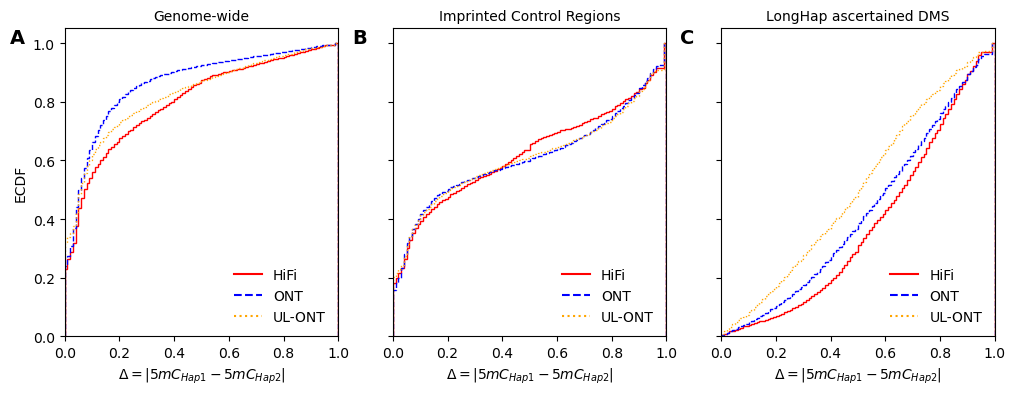

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)

handles = [Line2D([0], [0], color='red', ls='-', label='HiFi'),
           Line2D([0], [0], color='blue', ls='--', label='ONT'),
           Line2D([0], [0], color='orange', ls=':', label='UL-ONT')]

ax[0].hist(np.abs(df_hifi.ratio_1 - df_hifi.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_hifi.shape[0], df_hifi.shape[0]), histtype='step', label='HiFi',
          color='red', ls='-')
ax[0].hist(np.abs(df_ont.ratio_1 - df_ont.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ont.shape[0], df_ont.shape[0]), histtype='step', label='ONT',
          color='blue', ls='--')
ax[0].hist(np.abs(df_ul_ont.ratio_1 - df_ul_ont.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ul_ont.shape[0], df_ul_ont.shape[0]), histtype='step', label='UL-ONT',
          color='orange', ls=':')
ax[0].set_xlim([0, 1])
ax[0].set_xlabel(r'$\Delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')
ax[0].legend(handles=handles, frameon=False, loc='lower right')
ax[0].set_title('Genome-wide', fontsize=10)
ax[0].annotate("A", (-0.2, 1), xycoords=ax[0].transAxes, fontsize=14, fontweight='bold', ha='left', va='top')

ax[1].hist(np.abs(df_hifi_icr.ratio_1 - df_hifi_icr.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_hifi_icr.shape[0], df_hifi_icr.shape[0]), histtype='step', label='HiFi',
          color='red', ls='-')
ax[1].hist(np.abs(df_ont_icr.ratio_1 - df_ont_icr.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ont_icr.shape[0], df_ont_icr.shape[0]), histtype='step', label='ONT',
          color='blue', ls='--')
ax[1].hist(np.abs(df_ul_ont_icr.ratio_1 - df_ul_ont_icr.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ul_ont_icr.shape[0], df_ul_ont_icr.shape[0]), histtype='step', label='UL-ONT',
          color='orange', ls=':')
ax[1].set_xlim([0, 1])
ax[1].set_xlabel(r'$\Delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')
ax[1].legend(handles=handles, frameon=False, loc='lower right')
ax[1].set_title('Imprinted Control Regions', fontsize=10)
ax[1].annotate("B", (-0.15, 1), xycoords=ax[1].transAxes, fontsize=14, fontweight='bold', ha='left', va='top')


ax[2].hist(np.abs(df_hifi_longhap.ratio_1 - df_hifi_longhap.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_hifi_longhap.shape[0], df_hifi_longhap.shape[0]), histtype='step', label='HiFi',
          color='red', ls='-')
ax[2].hist(np.abs(df_ont_longhap.ratio_1 - df_ont_longhap.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ont_longhap.shape[0], df_ont_longhap.shape[0]), histtype='step', label='ONT',
          color='blue', ls='--')
ax[2].hist(np.abs(df_ul_ont_longhap.ratio_1 - df_ul_ont_longhap.ratio_2) / 100, bins=100, cumulative=True, 
        weights=np.repeat(1/df_ul_ont_longhap.shape[0], df_ul_ont_longhap.shape[0]), histtype='step', 
        label='UL-ONT', color='orange', ls=':')
ax[2].set_xlim([0, 1])
ax[2].set_xlabel(r'$\Delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')
ax[2].legend(handles=handles, frameon=False, loc='lower right')
ax[2].set_title('LongHap ascertained DMS', fontsize=10)
ax[2].annotate("C", (-0.15, 1), xycoords=ax[2].transAxes, fontsize=14, fontweight='bold', ha='left', va='top')

ax[0].set_ylabel('ECDF')


Text(0, 0.5, 'LongHap inferred $\\Delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')

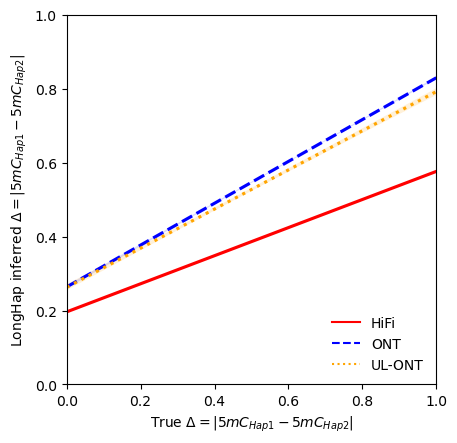

In [11]:
fig, ax = plt.subplots()

sns.regplot(x=np.abs(df_hifi_longhap.ratio_1 - df_hifi_longhap.ratio_2) / 100, 
            y=np.abs(df_hifi_longhap.ratio_hap1 - df_hifi_longhap.ratio_hap2) / 100, ax=ax,
            scatter=False, line_kws={"ls": '-'}, color='red')

sns.regplot(x=np.abs(df_ont_longhap.ratio_1 - df_ont_longhap.ratio_2) / 100, 
            y=np.abs(df_ont_longhap.ratio_hap1 - df_ont_longhap.ratio_hap2) / 100, ax=ax,
            scatter=False, line_kws={"ls": '--'}, color='blue')

sns.regplot(x=np.abs(df_ul_ont_longhap.ratio_1 - df_ul_ont_longhap.ratio_2) / 100, 
            y=np.abs(df_ul_ont_longhap.ratio_hap1 - df_ul_ont_longhap.ratio_hap2) / 100, ax=ax,
            scatter=False, line_kws={"ls": ':'}, color='orange')

ax.legend(handles=handles, frameon=False, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_aspect('equal')
ax.set_xlabel('True ' + r'$\Delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')
ax.set_ylabel('LongHap inferred ' + r'$\Delta=|5mC_{Hap 1}-5mC_{Hap 2}|$')


In [12]:
np.sum(np.abs(df_ul_ont_longhap.ratio_1 - df_ul_ont_longhap.ratio_2) > 40) / np.abs(df_ul_ont_longhap.ratio_1 - df_ul_ont_longhap.ratio_2).shape[0]

np.float64(0.6286703601108034)

In [28]:
np.abs(df_ul_ont.ratio_1 - df_ul_ont.ratio_2).shape[0]

23611281

Text(0.5, 0, 'Fold-change ')

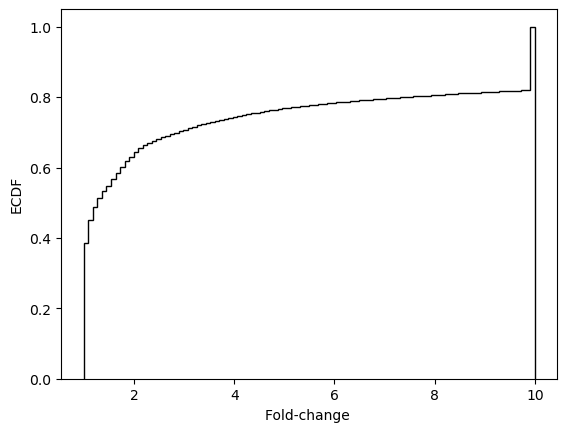

In [26]:
fig, ax = plt.subplots()

ax.hist(np.clip(np.where(df_hifi.ratio_1 >= df_hifi.ratio_2, (df_hifi.ratio_1 + 1e-20) / (df_hifi.ratio_2 + 1e-20), 
                 (df_hifi.ratio_2 + 1e-20) / (1e-20 + df_hifi.ratio_1)), 1, 10) , bins=100, cumulative=True, 
        weights=np.repeat(1/df_hifi.shape[0], df_hifi.shape[0]), histtype='step',
          color='black', ls='-')

ax.set_ylabel('ECDF')
ax.set_xlabel('Fold-change ')


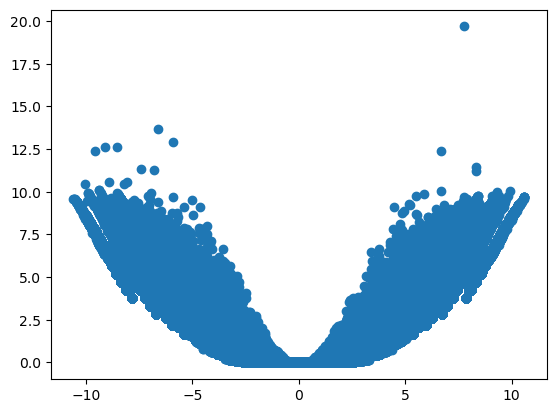

In [39]:
from fisher import pvalue_npy          # pip install fisher — vectorized, fast
from statsmodels.stats.multitest import multipletests
m1 = df_hifi.mod_count_1.values
m2 = df_hifi.mod_count_2.values
um1 = df_hifi.unmod_count_1.values
um2 = df_hifi.unmod_count_2.values


_, _, p = pvalue_npy(m1.astype(np.uint32), um1.astype(np.uint32),
                     m2.astype(np.uint32), um2.astype(np.uint32))
qval = multipletests(p, method='fdr_bh')[1]

# effect size — pseudocount avoids the 0/inf clipping in your ECDF
eps = 0.5
f1 = (m1 + eps) / (um1 + 2 * eps)
f2 = (m2 + eps) / (um2 + 2 * eps)
log2fc = np.log2(f1 / f2)
delta  = f1 - f2    



Text(0.5, 0, 'Log 2 (5mC Haplotype 1/5mC Haplotype 2)')

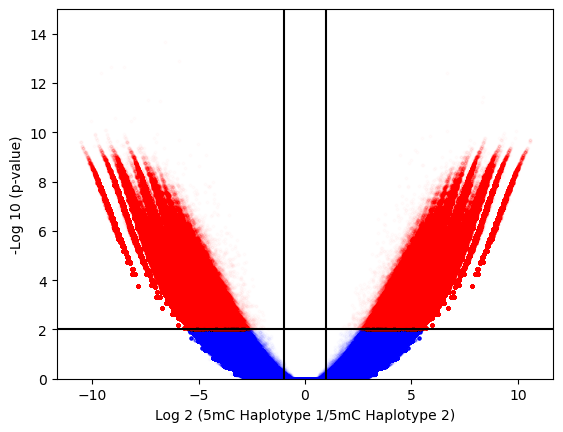

In [47]:
fig, ax = plt.subplots()

ax.scatter(log2fc[-np.log10(qval) <= 2], -np.log10(qval)[-np.log10(qval) <= 2], alpha=0.01, color='blue', s=4)
ax.scatter(log2fc[-np.log10(qval) > 2], -np.log10(qval)[-np.log10(qval) > 2], alpha=0.01, color='red', s=4)
ax.axhline(2, color='black')
ax.axvline(-1, color='black')
ax.axvline(1, color='black')
ax.set_ylim([0, 15])
ax.set_ylabel("-Log 10 (p-value)")
ax.set_xlabel("Log 2 (5mC Haplotype 1/5mC Haplotype 2)")

In [46]:
(-np.log10(qval) > 2).sum() / qval.shape[0]

np.float64(0.12085343233948695)